In [1]:
import sys,os
import pandas as pd
from ultron.datasets.generate import create_data

In [2]:
sys.path.insert(0, os.path.abspath('../'))
from lumina.orders.const import OrderTuple
from lumina.orders.drawer import plot_his_trade

ModuleNotFoundError: No module named 'lumina.orders.drawer'

In [3]:
def create_factors(start_date, end_date, m=30, n=10, res_name=None):
    date_index = pd.date_range(start=start_date, end=end_date, freq='T')
    date_index.name = 'trade_time'
    codes = ["code_" + str(i) for i in range(0, n)]

    factors_res = [
        create_data(date_index=date_index,
                    codes=codes,
                    name="factor_{}".format(str(i))) for i in range(0, m)
    ]
    if isinstance(res_name, str):
        factors_res.append(
            create_data(date_index=date_index, codes=codes, name=res_name))
    factors_data = pd.concat(factors_res, axis=1)

    factors_data = factors_data.reset_index().rename(
        columns={'level_1': 'code'})
    return factors_data

In [4]:
start_time = "2023-01-01 00:20:00"
end_time = "2023-01-01 00:59:59"

kl_pd = create_factors(start_time, end_time, m=7, n=1, res_name='res')
kl_pd.rename(columns={
        'factor_0': 'high',
        'factor_1': 'low',
        'factor_2': 'open',
        'factor_3': 'close',
        'factor_4': 'volume',
        'factor_5': 'amount',
        'factor_6': 'rate',
        'res': 'nxt1_ret'
    },
                 inplace=True)

In [5]:
kl_pd.index = kl_pd['trade_time']
kl_pd['key'] = list(range(0, len(kl_pd)))

In [6]:
#kl_pd#.loc['2023-01-01 00:32:00']['close']

In [7]:
orders = []
buy_time1 = '2023-01-01 00:24:00'
sell_time1 = '2023-01-01 00:30:00'

buy_time2 = '2023-01-01 00:40:00'
sell_time2 = '2023-01-01 00:55:00'
orders.append(OrderTuple(
    buy_time=buy_time1,
    buy_price=kl_pd.loc[buy_time1]['close'],
    buy_cnt=100,
    sell_time = sell_time1,
    sell_price=kl_pd.loc[sell_time1]['close'],
    sell_type='win',
    expect_direction=-1,
    buy_symbol='code_0',
))

orders.append(OrderTuple(
    buy_time=buy_time2,
    buy_price=kl_pd.loc[buy_time2]['close'],
    buy_cnt=100,
    sell_time = sell_time2,
    sell_price=kl_pd.loc[sell_time2]['close'],
    sell_type='loss',
    expect_direction=1,
    buy_symbol='code_0',
))

In [8]:
orders

[OrderTuple(buy_time='2023-01-01 00:24:00', buy_price=0.9127424956812726, buy_cnt=100, sell_time='2023-01-01 00:30:00', sell_price=0.5852159479576687, sell_type='win', expect_direction=-1, buy_symbol='code_0'),
 OrderTuple(buy_time='2023-01-01 00:40:00', buy_price=0.19212070250163138, buy_cnt=100, sell_time='2023-01-01 00:55:00', sell_price=0.634674088551809, sell_type='loss', expect_direction=1, buy_symbol='code_0')]

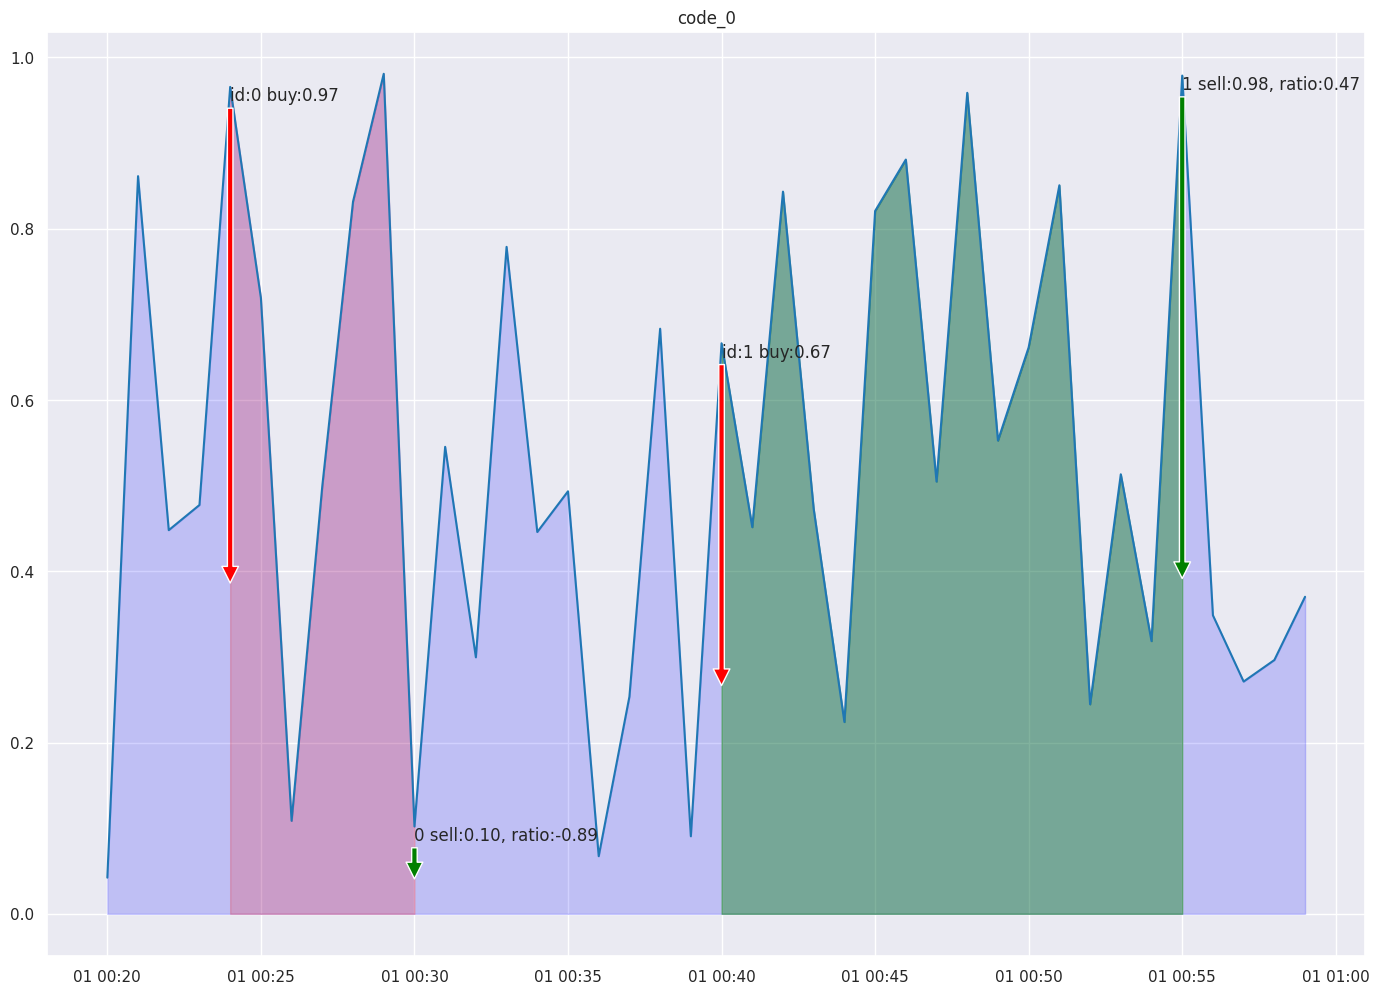

In [8]:
plot_his_trade(kl_pd=kl_pd, orders=orders)